In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error


In [15]:
base = "C:/Users/monke/Downloads"

df = pd.read_csv(f"{base}/fullField.csv")
test = pd.read_csv(f"{base}/strawberry.csv")

In [36]:
from sklearn.ensemble import RandomForestRegressor
features = ['SEN_NDVI_Band_1', 'B2_Clip_Band_1', 'B3_Clip_Band_1', 'B4_Clip_Band_1',
    'B5_Clip_Band_1', 'B6_Clip_Band_1', 'B7_Clip_Band_1',
    'B8_Clip_Band_1', 'B8A_Clip_Band_1',
    'B11_Clip_Band_1', 'B12_Clip_Band_1'
]
target = 'UAV_NDVI1_Band_1'

X = test[features]
y = test[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
model.fit(X, y)

y_pred = model.predict(X_test)

# --- evaluate ---
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"R²: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")

R²: 0.1341
RMSE: 0.0806


In [17]:
import numpy as np
import pandas as pd

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score, mean_squared_error

from xgboost import XGBRegressor

# --- model dictionary ---
models = {
    'LinearRegression': LinearRegression(),
    'Ridge': Ridge(alpha=1.0),
    'Lasso': Lasso(alpha=0.001),

    'RandomForest': RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1),
    'ExtraTrees': ExtraTreesRegressor(n_estimators=200, random_state=42, n_jobs=-1),
    'GradientBoosting': GradientBoostingRegressor(n_estimators=200, learning_rate=0.05, random_state=42),

    'XGBoost': XGBRegressor(n_estimators=200, learning_rate=0.05, random_state=42, n_jobs=-1),

    'SVR': SVR(kernel='rbf', C=10, epsilon=0.1),
    'KNN': KNeighborsRegressor(n_neighbors=5)
}

# --- results storage ---
results = []

# --- loop ---
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    res = {
        'model': name,
        'r2': r2,
        'rmse': rmse
    }
    print(res)
    results.append(res)

# --- convert to DataFrame for easy viewing ---
results_df = pd.DataFrame(results).sort_values(by='r2', ascending=False)


{'model': 'LinearRegression', 'r2': 0.262641156166758, 'rmse': np.float64(0.12965004749038217)}
{'model': 'Ridge', 'r2': 0.2626375458163208, 'rmse': np.float64(0.12965036489454473)}
{'model': 'Lasso', 'r2': 0.26190784427795666, 'rmse': np.float64(0.12971450070452742)}
{'model': 'RandomForest', 'r2': 0.9622023780264028, 'rmse': np.float64(0.029353877129949624)}
{'model': 'ExtraTrees', 'r2': 0.9662787192191759, 'rmse': np.float64(0.0277258752036692)}
{'model': 'GradientBoosting', 'r2': 0.691730356096961, 'rmse': np.float64(0.08382983547346909)}
{'model': 'XGBoost', 'r2': 0.8999315803851429, 'rmse': np.float64(0.04776191748004712)}
{'model': 'SVR', 'r2': 0.526849252040773, 'rmse': np.float64(0.10385633649599246)}
{'model': 'KNN', 'r2': 0.9244028787640463, 'rmse': np.float64(0.041513166592845624)}


C:\Users\monke\AppData\Local\Temp\ipykernel_1976\1564256236.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(results_df['model'], rotation=45)


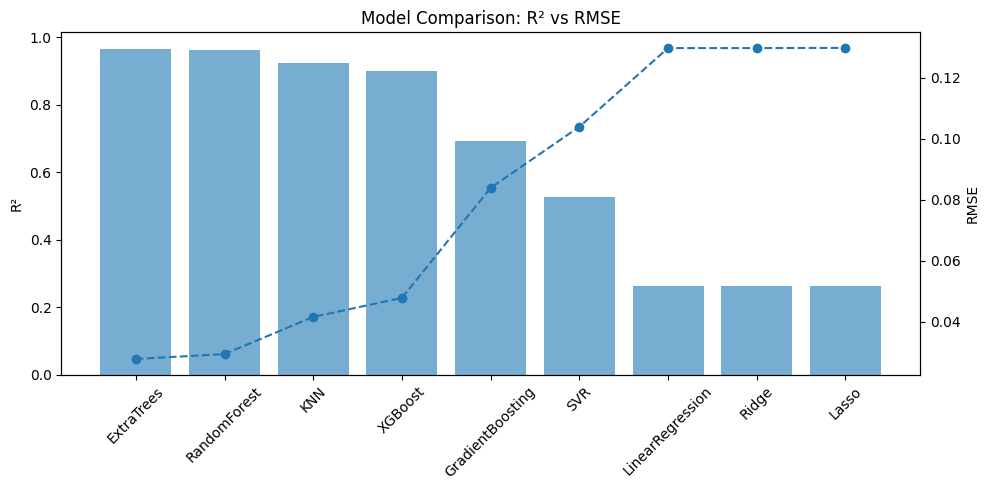

In [18]:
import matplotlib.pyplot as plt

# Ensure sorted
results_df = results_df.sort_values(by='r2', ascending=False)

fig, ax1 = plt.subplots(figsize=(10,5))

# R² (left axis)
ax1.bar(results_df['model'], results_df['r2'], alpha=0.6)
ax1.set_ylabel('R²')
ax1.set_xticklabels(results_df['model'], rotation=45)

# RMSE (right axis)
ax2 = ax1.twinx()
ax2.plot(results_df['model'], results_df['rmse'], marker='o', linestyle='--')
ax2.set_ylabel('RMSE')

plt.title('Model Comparison: R² vs RMSE')
plt.tight_layout()
plt.show()

In [29]:

model = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
model.fit(X, y)

y_pred = model.predict(X_test)

# --- evaluate ---
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"R²: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")

R²: 0.9980
RMSE: 0.0068


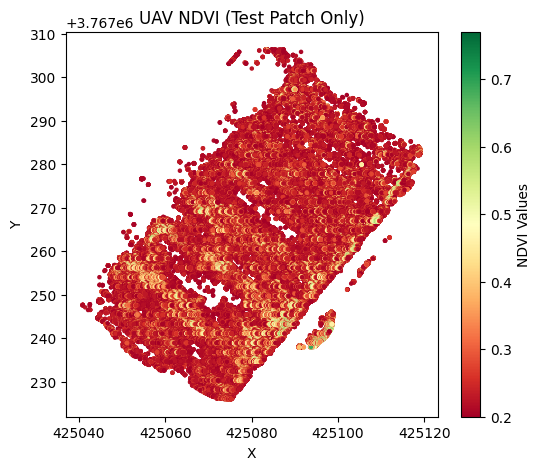

KeyError: '[564469, 557289, 2382322, 1462468, 686529, 967364, 182944, 930228, 1287965, 2431620, 483103, 683827, 1723520, 654201, 2708907, 1955327, 1144658, 2643376, 2115897, 2472608, 1910971, 966838, 920869, 1230902, 2228582, 145389, 2451144, 855151, 56699, 655358, 1540587, 1346618, 1926231, 1957493, 2474578, 2526223, 202556, 1281204, 1374488, 1895600, 1890027, 1182957, 724044, 1356912, 1113457, 1141332, 1147352, 747602, 1032197, 1619880, 546920, 1170346, 2410325, 2457610, 126679, 1684142, 66333, 2537348, 1909367, 131593, 2095594, 2194929, 2616532, 1280797, 1435480, 2467022, 2168354, 2557538, 354262, 557321, 783148, 407359, 2429283, 89719, 1441978, 1868890, 2655044, 1753511, 1109983, 2103028, 2291513, 304925, 2292553, 1621337, 64544, 135992, 1052179, 1899089, 1095179, 1606362, 2651763, 297083, 1672366, 695469, 666640, 264842, 970971, 1402233, 1708203, 802122, 1666635, 471988, 2382570, 1071547, 2284591, 556881, 2532001, 1754022, 1028265, 378780, 259405, 862901, 384484, 539830, 2091226, 

<Figure size 600x500 with 0 Axes>

In [37]:
import matplotlib.pyplot as plt
plt.figure(figsize=(6,5))

plt.scatter(
    test['X'],
    test['Y'],
    c=test['UAV_NDVI1_Band_1'],
    cmap='RdYlGn',
    s=5
)

plt.colorbar(label='NDVI Values')
plt.title('UAV NDVI (Test Patch Only)')
plt.xlabel('X')
plt.ylabel('Y')
plt.show()

plt.figure(figsize=(6,5))

plt.scatter(
    df.loc[y_test.index, 'X'],
    df.loc[y_test.index, 'Y'],
    c=y_pred,
    cmap='RdYlGn',
    s=5
)

plt.colorbar(label='NDVI Values')
plt.title('Predicted NDVI')
plt.xlabel('X')
plt.ylabel('Y')
plt.show()
plt.figure(figsize=(6,5))

plt.scatter(
    df.loc[y_test.index, 'X'],
    df.loc[y_test.index, 'Y'],
    c=df.loc[y_test.index, 'SEN_NDVI_Band_1'],
    cmap='RdYlGn',
    s=5
)

plt.colorbar(label='NDVI Values')
plt.title('SEN NDVI')
plt.xlabel('X')
plt.ylabel('Y')
plt.show()

In [21]:
n_unique = X_test['B3_Clip_Band_1'].nunique()

print("Number of unique values:", n_unique)

Number of unique values: 47
